# 05 — Model Evaluation & Error Analysis
**Purpose:** Deeper dive into the best model's performance: residual analysis, prediction-vs-actual plots, error by segment (city/property type), and a written summary for the final report.

**Input:** `models/best_model.pkl`, `data/processed/test.csv`
**Output:** Figures in `reports/figures/`, `reports/evaluation_summary.md`


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

best_model = joblib.load("../models/best_model.pkl")
test = pd.read_csv("../data/processed/test.csv")
comparison = pd.read_csv("../models/model_comparison.csv")

print("Loaded model:", type(best_model).__name__)
comparison


Loaded model: XGBRegressor


,Model,MAE (INR),RMSE (INR),R2 Score,MAPE (%)
0,XGBoost,1414993.0,3032542.0,0.8579,25.30
1,Random Forest,1378931.0,3267047.0,0.8350,23.86
2,Gradient Boosting,1567751.0,3323042.0,0.8293,27.63
3,Decision Tree,1709196.0,3984280.0,0.7547,29.76
4,Linear Regression,3150461.0,14803737.0,-2.3870,50.03


In [2]:
X_test = test.drop(columns=["price", "log_price"])
y_test_price = test["price"]

pred_log = best_model.predict(X_test)
pred_price = np.clip(np.expm1(pred_log), 0, None)

test_eval = test.copy()
test_eval["predicted_price"] = pred_price
test_eval["error"] = test_eval["predicted_price"] - test_eval["price"]
test_eval["abs_pct_error"] = (test_eval["error"].abs() / test_eval["price"]) * 100

test_eval[["price", "predicted_price", "error", "abs_pct_error"]].describe()


,price,predicted_price,error,abs_pct_error
count,2.472000e+03,2.472000e+03,2.472000e+03,2472.000000
mean,6.493559e+06,6.186922e+06,-3.066369e+05,25.295268
std,8.045458e+06,7.362076e+06,3.017609e+06,35.403882
min,2.650000e+05,3.318481e+05,-4.071839e+07,0.027092
25%,1.688247e+06,1.730266e+06,-6.912191e+05,7.874951
50%,4.394500e+06,4.288207e+06,-2.310825e+04,16.709882
75%,7.500000e+06,6.975566e+06,4.862151e+05,31.289121
max,1.000000e+08,9.174961e+07,2.279498e+07,745.586667


## 1. Predicted vs Actual Price

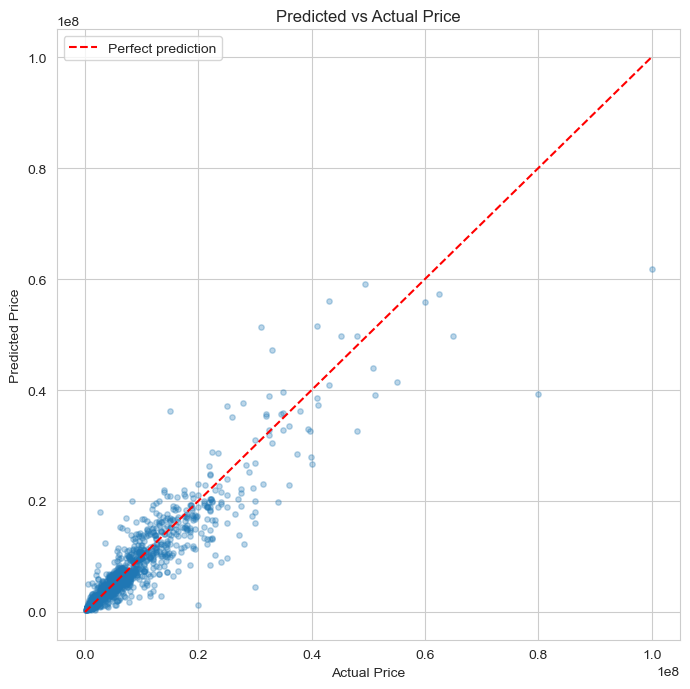

In [3]:
plt.figure(figsize=(7, 7))
sample = test_eval.sample(min(2000, len(test_eval)), random_state=42)
plt.scatter(sample["price"], sample["predicted_price"], alpha=0.3, s=15)
max_val = max(sample["price"].max(), sample["predicted_price"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/predicted_vs_actual.png", dpi=120)
plt.show()


## 2. Residual Distribution

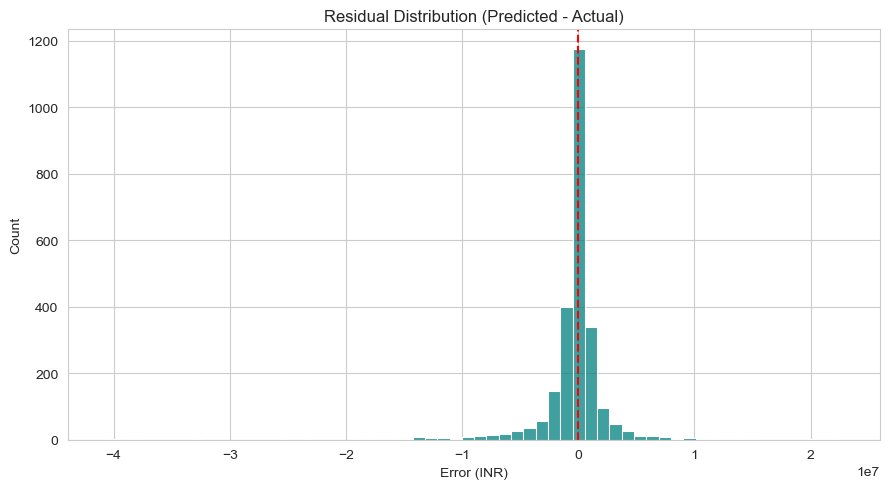

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(test_eval["error"], bins=60, color="teal")
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution (Predicted - Actual)")
plt.xlabel("Error (INR)")
plt.tight_layout()
plt.savefig("../reports/figures/residual_distribution.png", dpi=120)
plt.show()


## 3. Error by City / Property Type
Reconstruct the original city/property_type columns from the one-hot encoded test set for segment-level error analysis.

In [5]:
city_cols = [c for c in test_eval.columns if c.startswith("city_")]
type_cols = [c for c in test_eval.columns if c.startswith("property_type_")]

def decode_onehot(row, cols, prefix, default):
    for c in cols:
        if row[c] == 1:
            return c.replace(prefix, "")
    return default

test_eval["city_decoded"] = test_eval.apply(lambda r: decode_onehot(r, city_cols, "city_", "Base/Reference"), axis=1)
test_eval["property_type_decoded"] = test_eval.apply(lambda r: decode_onehot(r, type_cols, "property_type_", "Base/Reference"), axis=1)

seg_error = test_eval.groupby("city_decoded")["abs_pct_error"].mean().sort_values()
seg_error


city_decoded
Ghaziabad         19.350344
Base/Reference    23.810869
Lucknow           33.424601
Pune              34.600868
Name: abs_pct_error, dtype: float64

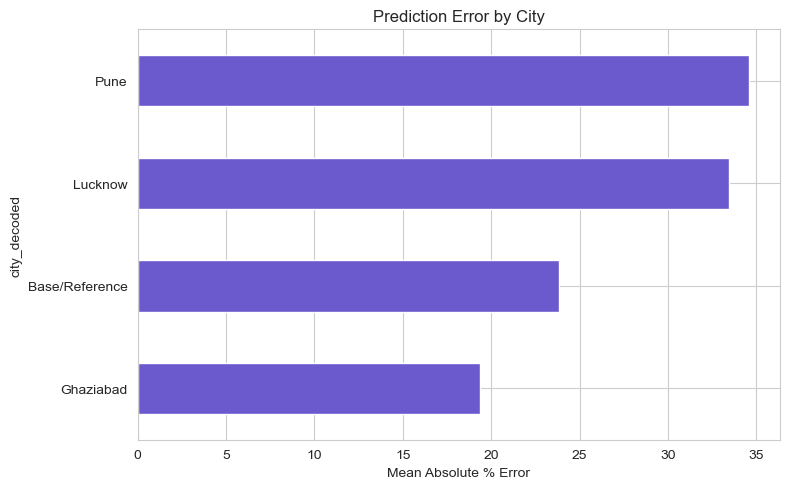

In [6]:
plt.figure(figsize=(8, 5))
seg_error.plot(kind="barh", color="slateblue")
plt.xlabel("Mean Absolute % Error")
plt.title("Prediction Error by City")
plt.tight_layout()
plt.savefig("../reports/figures/error_by_city.png", dpi=120)
plt.show()


## 4. Overall Metrics Summary

In [7]:
mae = mean_absolute_error(y_test_price, pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
r2 = r2_score(y_test_price, pred_price)
mape = test_eval["abs_pct_error"].mean()

summary = f"""
Best model: {type(best_model).__name__}
MAE: Rs. {mae:,.0f}
RMSE: Rs. {rmse:,.0f}
R2 Score: {r2:.4f}
MAPE: {mape:.2f}%
"""
print(summary)



Best model: XGBRegressor
MAE: Rs. 1,414,993
RMSE: Rs. 3,032,542
R2 Score: 0.8579
MAPE: 25.30%



## 5. Write Evaluation Summary to Report

In [8]:
with open("../reports/evaluation_summary.md", "w") as f:
    f.write("# Model Evaluation Summary\n\n")
    f.write(f"**Best model:** {type(best_model).__name__}\n\n")
    f.write("## Overall Metrics\n")
    f.write(f"- MAE: Rs. {mae:,.0f}\n")
    f.write(f"- RMSE: Rs. {rmse:,.0f}\n")
    f.write(f"- R2 Score: {r2:.4f}\n")
    f.write(f"- MAPE: {mape:.2f}%\n\n")
    f.write("## Model Comparison\n\n")
    f.write(comparison.to_markdown(index=False))
    f.write("\n\n## Error by City\n\n")
    f.write(seg_error.round(2).to_markdown())
    f.write("\n")

print("Saved reports/evaluation_summary.md")


Saved reports/evaluation_summary.md


## 6. Limitations & Notes (fill in for report)
- Dataset combines listing sources across 4 cities — pricing conventions/data quality may differ by source.
- Several original amenity columns (project_score, builder_experience, etc.) were dropped due to >75% missing values — these could add signal if re-collected.
- Model predicts *listed* price, not necessarily transaction/sale price.
- MAPE by city shows where the model is weakest — worth targeted feature engineering for those cities.

---
**Next step:** `app/app.py` — Streamlit dashboard using `models/best_model.pkl`, `models/scaler.pkl`, and `models/feature_columns.pkl` for a live prediction demo.
